# 분류와 평가지표

1. 분류란 무엇인가?
2. 여섯가지 알고리즘 비교
3. KNN 
4. 앙상블 - 배깅과 부스팅
5. 평가지표

In [3]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from _style import setup
from _ml import build_dataset, FEATURES, SEED, time_split, load_merged

setup()
pd.set_option("display.width", 130)

df = build_dataset()            
train, test, cutoff = time_split(df)

tr = train.sample(15000, random_state=SEED)
te = test.sample(4000, random_state=SEED)

X_train, y_train = tr[FEATURES], tr["target_up"]
X_test, y_test = te[FEATURES], te["target_up"]

print(f" 학습 {len(tr):,}행 ({tr.date.min().date()} ~ {tr.date.max().date()})")
print(f" 테스트 {len(te):,}행 ({te.date.min().date()} ~ {te.date.max().date()})")
print(f"상승 비율   학습 {y_train.mean():.4f} / 테스트 {y_test.mean():.4f}")

[폰트] Malgun Gothic / unicode_minus=False
 학습 15,000행 (2023-10-24 ~ 2026-01-16)
 테스트 4,000행 (2026-01-19 ~ 2026-08-07)
상승 비율   학습 0.4931 / 테스트 0.4825


---
# 1. 분류란 무엇인가?

**범주를 예측하는 문제**다. 

|종류|예|
|---|---|
|이진 분류|상승/하락, 스팸여부, 연체여부...|
|다중 분류|섹터예측, 신용등급(1,2,3,4..)...|

우리는 이진분류를 중점적으로 다루겠다. 
-> 지표가 명확하고 가장 많이 사용하는 형태라서.

수익률, 거래량비율, 이평대비, 변동성 -> up / down

> 오늘 장이 끝나기 전에, 오늘 주식이 오를 것이가를 예측한다.

---
# 2. 여섯 가지 알고리즘

> 사용법 - 모든 알고리즘을 동일하게 사용할 수 있다.
> model = 어떤모델()
> model.fit(X_train, y_train)
> pred = model.predict(X_test)
> score = model.score(X_test, y_test)

|모델|스케일링|속도|해석|성능|
|---|---|---|---|---|
|LogisticRegression|필요|빠름|O|보통|
|DecisionTree|불필요|빠름|O|낮음|
|KNN|필수|예측이느림|△|보통|
|RandomForest|불필요|보통|△|좋음|
|SVM|필요|매우느림|X|그때그때다름|
|GradientBoosting|불필요|느림|△|좋음|

In [4]:
from sklearn.dummy import DummyClassifier #다른 모델 성능을 비교할 기준선을 만드는 분류기
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier # 여러개의 알고리즘이 합처진 RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression #선형모델
from sklearn.metrics import accuracy_score, f1_score # accuracy_score(정확도), f1_score(정밀도, 재현률의 평균)
from sklearn.neighbors import KNeighborsClassifier # KNN 모델
from sklearn.pipeline import Pipeline # 데이터 전처리부터 모델 학습과정을 하나로 묶을 수 있게 해주는 도구
from sklearn.preprocessing import StandardScaler # 각 피처의 평균을 0, 표준편차를 1로 만들어 데이터 단위 맞춰주는 전처리 도구
from sklearn.svm import SVC # svm모델
from sklearn.tree import DecisionTreeClassifier # 의사결정나무

# 스케일링이 필요한 모델은 Pipeline으로 묶어준다.
def with_scaler(model):
    return Pipeline([("sc", StandardScaler()), ("m", model)])

# SVM은 데이터 수의 제곱에 비례해 느려짐. 표본을 줄여서 사용.
SVM_N = 3000

models = {
    "DummyClassifier": (DummyClassifier(strategy="most_frequent"), False),
    "LogisticRegression": (with_scaler(LogisticRegression(max_iter=1000, random_state=SEED)), False),
    "DecisionTree(제한)": (DecisionTreeClassifier(max_depth=5, random_state=SEED), False),
    "DecisionTree(제한없음)": (DecisionTreeClassifier(random_state=SEED), False),
    "KNN(k-50)": (with_scaler(KNeighborsClassifier(n_neighbors=50, n_jobs=-1)), False),
    "RandomForest" : (RandomForestClassifier(n_estimators=100, max_depth=6, random_state=SEED, n_jobs=-1), False),
    "GradientBoosting" : (GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=SEED), False),
    "SVM(표본3천개)" : (with_scaler(SVC(random_state=SEED)), True)
}

rows = []
for name, (model, small) in models.items():
    #SVM만 작은 표본으로 진행
    Xtr = X_train.iloc[:SVM_N] if small else X_train
    ytr = y_train.iloc[:SVM_N] if small else y_train

    t0 = time.perf_counter()
    model.fit(Xtr, ytr)
    fit_time = time.perf_counter() - t0

    pred = model.predict(X_test)
    rows.append({
        "모델": name,
        "학습": model.score(Xtr, ytr),
        "테스트" : accuracy_score(y_test, pred),
        "F1" : f1_score(y_test, pred, zero_division=0),
        "학습시간": fit_time,
    })

result = pd.DataFrame(rows)
print(result.round(4).to_string(index=False))

                모델     학습    테스트     F1   학습시간
   DummyClassifier 0.5069 0.5175 0.0000 0.0177
LogisticRegression 0.5107 0.4805 0.3859 0.0106
  DecisionTree(제한) 0.5219 0.4810 0.5245 0.0388
DecisionTree(제한없음) 1.0000 0.5005 0.4893 0.1501
         KNN(k-50) 0.5672 0.5178 0.4708 0.0113
      RandomForest 0.6105 0.4932 0.4269 0.2290
  GradientBoosting 0.5987 0.4960 0.4434 2.2748
        SVM(표본3천개) 0.5720 0.4915 0.3787 0.1412


### 확인할 떄

**DummyClassifier** - 항상 다수 클래스만 답하는 모델. 이값이 기준이된다. 이것보다 못하면 그 모델은 사용자체가 불가함.

**DecisionTree(제한없음)** - 학습 정확도가 1.0000이다. 학습데이터를 외운거다. 테스트와의 차이가 크다 -> 과적합

**SVM** - 표본이 1/5 수준인데도 느리다. 계산량이 데이터 수의 제곱으로 비례한다. 

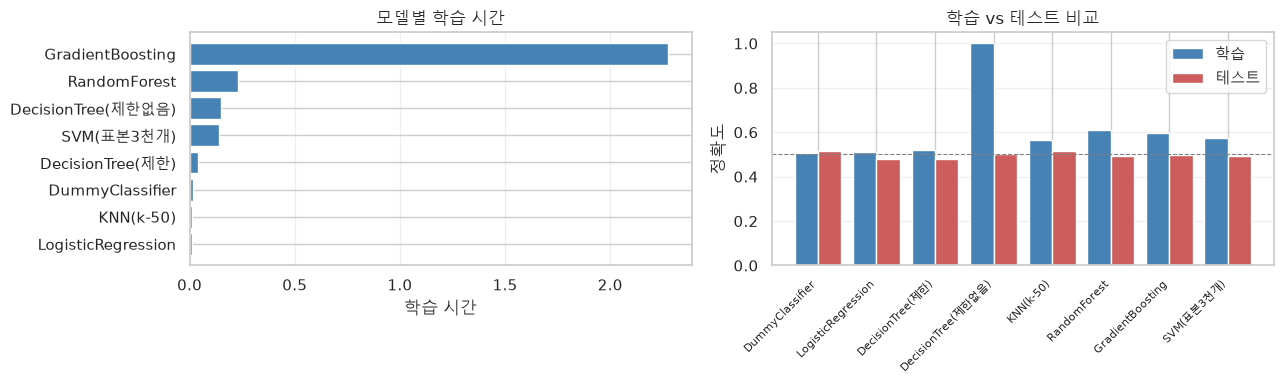

In [5]:
# 학습시간을 그림으로 비교해보자
fig, axes = plt.subplots(1,2, figsize=(13,4))

r = result.sort_values("학습시간")
axes[0].barh(r["모델"], r["학습시간"], color="steelblue")
axes[0].set_xlabel("학습 시간")
axes[0].set_title("모델별 학습 시간")
axes[0].grid(alpha=0.3, axis="x")

#학습 vs 테스트 비교
x = np.arange(len(result))
axes[1].bar(x - 0.2, result["학습"], 0.4, label="학습", color="steelblue")
axes[1].bar(x + 0.2, result["테스트"], 0.4, label="테스트", color="indianred")
axes[1].set_xticks(x) # x축 눈금의 기본위치
axes[1].set_xticklabels(result["모델"], rotation=45, ha="right", fontsize=8)
axes[1].axhline(0.5, color="gray", ls="--", lw=0.8)
axes[1].set_ylabel("정확도")
axes[1].set_title("학습 vs 테스트 비교")
axes[1].legend()
axes[1].grid(alpha=0.3, axis="y")

fig.tight_layout()
plt.show()


# KNN - 가장 가까운 K개의 샘플을 찾아서 다수결로 결정

끼리끼리 모인다. -> K값으로 과적합을 조절할 수 있다.

|장점|단점|
|---|---|
|개념이 가장 단순|예측할 때마다 전체 거리를 계산|
|학습이 사실상 없음|예측시에 데이터가 많으면 느림|
|비선형 경계도 처리|스케일링 필수|

**KNN은 예측시에 계산하므로 학습이 거의 필요없다**
fit()에서는 데이터를 저장만 한다.

In [6]:
# K값을 변경하면서 학습, 테스트 서능을 보자.

ks = [1,3,5,10,15,30,50,100,200,500]

rows = []

for k in ks:
    knn = with_scaler(KNeighborsClassifier(n_neighbors=k, n_jobs=-1))
    knn.fit(X_train, y_train)
    tr_s = knn.score(X_train, y_train)
    te_s = knn.score(X_test, y_test)
    rows.append({"k" : k, "학습" : tr_s, "테스트" : te_s, "차이" : tr_s - te_s})

knn_result = pd.DataFrame(rows)
print(knn_result.round(4).to_string(index=False))

  k     학습    테스트     차이
  1 1.0000 0.5052 0.4948
  3 0.7562 0.4892 0.2669
  5 0.6916 0.4940 0.1976
 10 0.6273 0.5042 0.1230
 15 0.6115 0.5135 0.0980
 30 0.5845 0.5220 0.0625
 50 0.5672 0.5178 0.0494
100 0.5510 0.5110 0.0400
200 0.5334 0.4968 0.0366
500 0.5232 0.4938 0.0294


**k=1에서 학습 정확도가 1.0000이다**

자기 자신이 가장 가까운 이웃이기 때문에 완전히 답을 외우고 푸는 것과 동일하다. -> 전형적인 과적합.

k를 키우면 학습성능이 내려오면서 두값의 차이가 줄어듬. 더 키우면 결국 항상 다수 클래스에 가까워 진다. -> 과소적합



**+ KNN은 가장 가까운 거리를 구하는 것이기 때문에 항상 스케일링이 필수다.**

---
# 앙상블 - 배깅과 부스팅

여러 모델의 의견을 모으는 방식. 랜덤포레스트도 앙상블 방식이다.

|방식|어떻게|대표|
|---|---|---|
|보팅|서로 다른 알고리즘을 결합|직접 만들어서 사용|
|배깅|같은 알고리즘을 데이터를 달리하여 병렬학습|RandomForest|
|부스팅|약한 모델을 순차적으로 학습|XGBoost, LightGBM|

**배깅과 부스팅의 차이**

배깅은 여러 모델이 **동시에 따로**배우고 의경을 모으는 것. 분산을 줄여 과적합을 막는 전략

부스팅은 앞 모델이 **틀린 것을 다음 모델이 집중적으로**배우는 것. 편향을 줄여 성능을 높이는 전략

In [7]:
# 트리하나 -> 배깅 -> 부스팅

models = {
    "DecisionTree(트리1개)": DecisionTreeClassifier(max_depth=6, random_state=SEED),
    "RandomForest(배깅)" : RandomForestClassifier(n_estimators=100, max_depth=6, random_state=SEED, n_jobs=-1),
    "GradientBoosting(부스팅)" : GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=SEED),
}

rows = []

for name, m in models.items():
    t0 = time.perf_counter()
    m.fit(X_train, y_train)
    el = time.perf_counter() - t0
    rows.append({
        "모델": name,
        "학습": m.score(X_train, y_train),
        "테스트": m.score(X_test, y_test),
        "학습시간": el,
    })

ens = pd.DataFrame(rows)
print(ens.round(4).to_string(index=False))

                   모델     학습    테스트   학습시간
   DecisionTree(트리1개) 0.5279 0.4800 0.0487
     RandomForest(배깅) 0.6105 0.4932 0.2133
GradientBoosting(부스팅) 0.5987 0.4960 2.3044


**왜 여러개가 하나보다 나을까?**

트리 하나는 특정 패턴에 치우칩니다. 서로 다르게 치우친 트리 여러 개의 의견을 모으면 개별 오차를 줄일 수 있다.

**부스팅은 학습이 더 느리다.**

배깅은 병렬처리를 하지만 부스팅은 앞 트리의 결과를 받아서 작업을 진행하기 때문에(순차적) 병렬화가 안된다. 

---
# 5. 정확도만을 기준으로 판단하면?

연체 예측모델을 만들었다. 정확도가 97%다. 좋은모델일까?

> 전체 10,000명 중 연체자 300명(3%)

> 모델이 전원 정상처리하면 -> 9,700을 맞힘 -> 정확도 97% -> 연체자 정확도는 0%

In [8]:
print(f"{'기준선':>10}{'양성 비율':>12}{'전부 음성 정확도':>18}")
print("-"*50)
for th in [0.0,0.01,0.02,0.03,0.04,0.05]:
    ratio = (df["target_ret"] > th).mean()
    print(f"{th:>9.0%}{ratio:>12.2%}{1 - ratio:>18.4f}")

       기준선       양성 비율         전부 음성 정확도
--------------------------------------------------
       0%      48.95%            0.5105
       1%      29.46%            0.7054
       2%      15.30%            0.8470
       3%       6.74%            0.9326
       4%       2.86%            0.9714
       5%       1.38%            0.9862


In [9]:
from sklearn.metrics import precision_score, recall_score

#수익률 5%초과를 급등으로 지정.
TH_P = 0.05
y_tr = (tr["target_ret"] > TH_P).astype(int)
y_te = (te["target_ret"] > TH_P).astype(int)

models = {
    "Dummy(전부아니다)" : DummyClassifier(strategy="most_frequent"),
    "RandomForest" : RandomForestClassifier(n_estimators=100, max_depth=6, 
                                            random_state=SEED, n_jobs=-1),
    "RandomForest(balanced)" : RandomForestClassifier(n_estimators=100, max_depth=6, 
                                              random_state=SEED, n_jobs=-1, 
                                              class_weight="balanced"),
}

rows = []
for name, m in models.items():
    m.fit(X_train, y_tr)
    p = m.predict(X_test)
    rows.append({
        "모델" : name,
        "정확도" : accuracy_score(y_te, p),
        "정밀도" : precision_score(y_te, p, zero_division=0),
        "재현율" : recall_score(y_te, p, zero_division=0),
        "F1" : f1_score(y_te, p, zero_division=0),
    })

print(pd.DataFrame(rows).round(4).to_string(index=False))

                    모델    정확도   정밀도    재현율     F1
          Dummy(전부아니다) 0.9868 0.000 0.0000 0.0000
          RandomForest 0.9868 0.000 0.0000 0.0000
RandomForest(balanced) 0.5678 0.015 0.4906 0.0292


**전부 아니다**라고 답한 더미모델이 정확도가 98%이상이다.

그런데 재현율은 0이다. -> 찾고싶은 값은 한개도 못찾았다.

연체,불량,질병,이상거래... 실무에서 중요한 문제는 대부분 불균형데이터가 많다. -> 정확도가 높은 것은 아무 의미가 없다.

**class_weight="balanced"** 를 넣으면

소수 클래스에 가중치를 줘서 재현율이 올라간다. 대신 정확도와 정밀도가 떨어진다. 한족을 올리면 다른 한쪽이 내려간다.

가장 간단하게 불균형데이터를 대응하는 방법이다.

---
# 혼동행렬 - 모든 지표를 만드는 기준값

True / False -> 예측이 정답이랑 일치했냐?
Positive / Negative -> 모델이 무엇으로 예측했냐?

TP -> 맞다고 했고 맞았다.

FP -> 맞았다고 했고 틀렸다.

FN -> 틀렸다고 했고 틀렸다.

TN -> 틀렸다고 했고 맞았다.

교안에서 그림 확인.

---
# 정밀도, 재형율, F1

|지표|계산|질문|
|---|---|---|
|정확도|(TP + TN) / 전체|전체 중 얼마나 맞혔냐?|
|정밀도(Precision)|TP / (TP + FP)|맞았다고 한것 중 실제로 그러한 값은?|
|재현율(Recall)|TP / (TP+FN)|진짜 맞은 것 중에 맞춘 것은?|
|F1|정밀도, 재형율을 조화롭게 평균|둘의 균형|


정밀도 -> 분모가 "예측" 내가 실제로 잡은 것
재현율 -> 분모가 "실제" 내가 실제로 잡은 것

In [10]:
from sklearn.metrics import classification_report

print(classification_report(y_te, p, zero_division=0))

              precision    recall  f1-score   support

           0       0.99      0.57      0.72      3947
           1       0.02      0.49      0.03        53

    accuracy                           0.57      4000
   macro avg       0.50      0.53      0.38      4000
weighted avg       0.98      0.57      0.71      4000



**classification_report를 습관적으로 찍어보자**

support는 각 클래스의 실제 건수. 불균형 정도를 여기서 바로 볼 수 있다.

F1은 균정적이만 기계적으로 쓰지말고, 지금 내가 보려는 문제에서 어떤것이 중요한지 먼저 정의하고 사용하자.

---
# ROC 곡선과 AUC

분류모델은 사실 **확률**을 출력한다. `0.5`를 넘으면 양성이라고 판단하고 이하면 음성이라고 판단한다.

이 기준값(임계값)을 바꾸면 정밀도와 재현율이 함께 움직인다.
임계값을 0부터 1까지 바꿔가면서 그린 곡선이 ROC이고, 그 곡선의 아래면을 수치화한게 AUC.

기준값을 너무 엄격하게 잡으면 -> 확실한 사람만 환자로 판정이된다. 오진은 거의 0에 가깝게 수렴하지만
실제로 환자를 놓쳐 탐지율(TPR)은 바닥으로 떨어질 수 있다.

기준값을 너무 느슨하게 잡으면 -> 조금만 이상해도 환자로 판정하기 때문에 모든 환자를 다 찾아내 탐지율(TPR)이 100%가 되지만, 멀쩡한사람도 환자로 보는 오진(FPR)도 거의 100%가 된다.

In [11]:
from sklearn.metrics import roc_auc_score, roc_curve, RocCurveDisplay


# 수익률이 2%를 초과하는
TH = 0.02
y_tr2 = (tr["target_ret"] > TH).astype(int)
y_te2 = (te["target_ret"] > TH).astype(int)

model = RandomForestClassifier(n_estimators=100, max_depth=6, 
                               class_weight="balanced", random_state=SEED, n_jobs=-1)

model.fit(X_train, y_tr2)

pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1] # 양성일 확


# ROC곡선 아래 면적에 해당하는 값을 점수로 환산해서 반환
auc = roc_auc_score(y_te2, proba)
# fpr : 가짜양성비율
# tpr : 진짜양성비율
# thresholds : fpr, tprd을 만들때 사용한 기준값 목록
fpr, tpr, thresholds = roc_curve(y_te2, proba)

print(f"AUC = {auc:.4f}")
print()
print(f"{'AUC':<12}{'의미'}")
print("-"*30)
for v, m in [("1.0", "완벽"),("0.8~0.9", "좋음"),("0.7", "쓸만함"),("0.5", "랜덤과 다를바 없음")]:
    print(f"{v:<12}{m}")

AUC = 0.4806

AUC         의미
------------------------------
1.0         완벽
0.8~0.9     좋음
0.7         쓸만함
0.5         랜덤과 다를바 없음


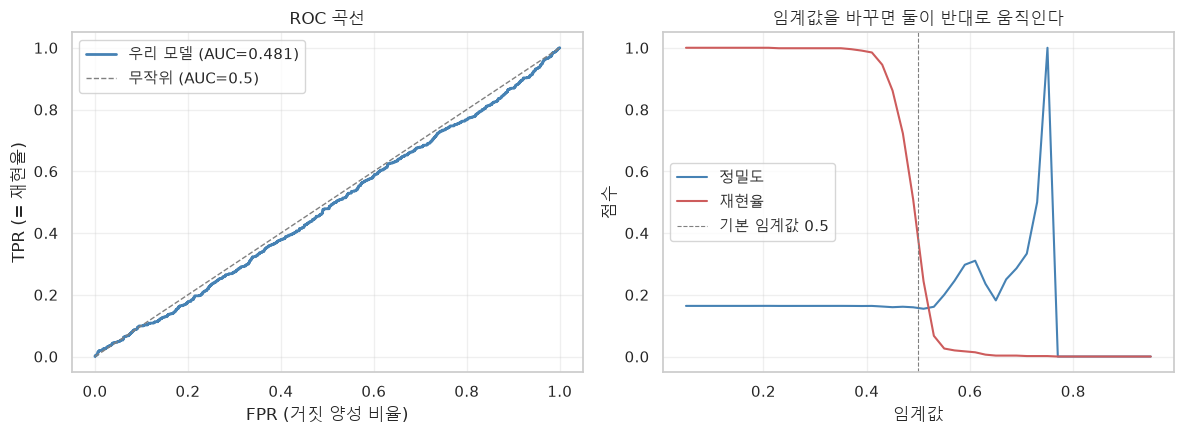

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))


#1. ROC곡선
axes[0].plot(fpr, tpr, lw=2, label=f"우리 모델 (AUC={auc:.3f})", color="steelblue")
axes[0].plot([0, 1], [0, 1], "--", color="gray", lw=1, label="무작위 (AUC=0.5)")
axes[0].set_xlabel("FPR (거짓 양성 비율)")
axes[0].set_ylabel("TPR (= 재현율)")
axes[0].set_title("ROC 곡선")
axes[0].legend()
axes[0].grid(alpha=0.3)

#2. 임계값이 따라서 두 지표가 어떻게 바뀌는지
ths = np.arange(0.05, 0.96, 0.02)

# proba가 t(임계값)이상이면 True, 미만이면 False 로 만들어서 정밀도, 재현율 다시 산출
precs = [precision_score(y_te2, (proba >= t).astype(int), zero_division=0) for t in ths]
recs = [recall_score(y_te2, (proba >= t).astype(int), zero_division=0) for t in ths]

axes[1].plot(ths, precs, label="정밀도", color="steelblue")
axes[1].plot(ths, recs, label="재현율", color="indianred")
axes[1].axvline(0.5, color="gray", ls="--", lw=0.8, label="기본 임계값 0.5")
axes[1].set_xlabel("임계값")
axes[1].set_ylabel("점수")
axes[1].set_title("임계값을 바꾸면 둘이 반대로 움직인다")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

** AUC는 임계값과 무관한 지표다 **
>
> 정확도, 정밀도, 재현율은 임계값을 정해야 계산이 가능하다.
> AUC는 **모든 임계값에서 성능을 종합**한 값이라, 모델 자체의 변별력을 확인할 수 있다.

**AUC가 높아도 실제로 못 쓸 수 있다**
>
> AUC는 순위를 얼마나 잘 매기는지를 봅니다.
> 그런데 운영에서는 **임계값 하나를 정해야** 데이터에 적합한 테스트가 가능하다.

> **AUC로 모델을 고르고, 임계값은 정밀도, 재현율을 보면서 따로 설정한다**

---
# 임계값 조정

기본값은 0.5로 되어있다. 급등탐지에서 재현율이 중요하다면 0.3으로 낮춰 더 많이 잡아낼 수 있을 것이다.

모델을 다시 학습시킬 필요없이 predict_proba의 출력에 따른 기준을 적용시켜주면 된다.

In [ ]:
print(f"{'임계값':>8}{'예측양성':>10}{'정밀도':>10}{'재현율':>10}{'F1':>9}")
print("-"*30)

for t in [0.2, 0.3 , 0.4, 0.5, 0.6, 0.7, 0.8]:
    p = (proba >= t).astype(int)
    print(f"{t:>8.1f}{p.sum():>10,}"
          f"{precision_score(y_te2, p, zero_division=0):>10.4f}"
          f"{recall_score(y_te2, p, zero_division=0):>10.4f}"
          f"{f1_score(y_te2, p, zero_division=0):>9.4f}")


     임계값      예측양성       정밀도       재현율       F1
------------------------------
     0.2     3,998    0.1641    1.0000   0.2819
     0.3     3,994    0.1640    0.9985   0.2817
     0.4     3,959    0.1634    0.9863   0.2804
     0.5     1,584    0.1566    0.3780   0.2214
     0.6        36    0.3056    0.0168   0.0318
     0.7         6    0.3333    0.0030   0.0060
     0.8         0    0.0000    0.0000   0.0000


**불균형 데이터(양성 데이터 부족)**
> 전체 실제 양성(1) 개수는 600~700개정도로 보인다. 전체 데이터 대비 진짜 양성 비율 자체가 매주 
> 적다보니, 아무리 재현율을 높여도 정밀도가 최대 33%밖에 나오지 않는다.

> 위 데이터로 보면 기본값 0.5는 절대 사용할 수 없다 -> 재현율이 37.8%로 대폭 하락하기 때문에.
> 기본적으로 f1-score가 높은 걸 사용하고, 만약 오답을 조금이라도 줄여야한다면 0.3~0.4정도를 사용할 수 있을 것 같다.

In [15]:
# F1이 최대가되는 임계값을 찾자.
f1s = [(t, f1_score(y_te2, (proba >= t).astype(int), zero_division=0))
       for t in np.arange(0.05, 0.96, 0.01)]

best_t, best_f1 = max(f1s, key=lambda x: x[1])
print(f"F1 최대 임계값 : {best_t} (F1 {best_f1:.4f})")
print(f"기본값 0.5  : F1 {f1_score(y_te2, pred, zero_division=0):.4f}")


# 재형율 조건을 만족하는 최소 임계값
T = 0.7
scores = [(t, recall_score(y_te2, (proba >= t).astype(int), zero_division=0),
       precision_score(y_te2, (proba >= t).astype(int), zero_division=0))
       for t in np.arange(0.05, 0.96, 0.01)]

result = [c for c in scores if c[1] >= T]

if result:
    t, r, p_ = max(result, key=lambda x: x[0]) # 조건을 만족하는 가장 높은 임계값
    print()
    print(f"재현율 {T} 이상을 만족하는 최대 임계값 : {t:.2f}")
    print(f" 그때 재현율 {r:.4f} / 정밀도 {p_:.4f}")


F1 최대 임계값 : 0.21000000000000002 (F1 0.2820)
기본값 0.5  : F1 0.2214

재현율 0.7 이상을 만족하는 최대 임계값 : 0.47
 그때 재현율 0.7226 / 정밀도 0.1613


**임계값은 반드시 검증데이터로 정해줘야한다**

테스트 데이터로 최적 임계값을 찾으면 테스트가 학습에 관여하게된다. 
-> 테스트는 마지막에 딱 한번만

**F1 최대가 항상 답은 아니다**

급등 종목 탐지라면 재현율 0.9 / 정밀도 0.1이 재현율 0.4 / 정밀도 0.4보다 나을 수 있다.

---
# 피처 중요도

트리 계열 모델은 어떤 피처가 판단에 많이 쓰였는지 알려준다.

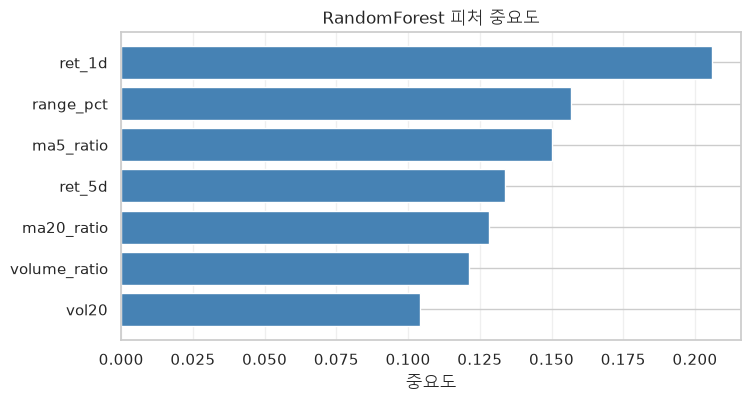

ret_1d          0.2058
range_pct       0.1568
ma5_ratio       0.1502
ret_5d          0.1338
ma20_ratio      0.1281
volume_ratio    0.1211
vol20           0.1042


In [16]:
imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8,4))
ax.barh(imp.index, imp.values, color="steelblue")
ax.set_xlabel("중요도")
ax.set_title("RandomForest 피처 중요도")
ax.grid(alpha=0.3,axis="x")
plt.show()

print(imp.sort_values(ascending=False).round(4).to_string())

**피처 중요도는 모델을 설명하는 근거가 된다.**

> "왜 이 고객이 연체 위험고객인지?" 판단의 기준을 답해야 할 수 있다.

**중요도가 인과관계를 뜻하지는 않는다**

> 거래량이 중요하다 -> 모델이 거래량을 많이 참조했다는 뜻이지, 거래량이 주가를 움직인다라는 
> 증거는 아니다. 
> 그리고 상관된 피처가 여럿이면 중요도가 그들 사이에 나뉘어 각각은 낮게 보일 수 있다.

---
# 정리
|개념|핵심|
|---|---|
|공통 인터페이스|모델 이름만 바꾸면 됨|
|DummyClassifier|기준 - 이것도바 못하면 쓸 수 없다|
|KNN|k가 작으면 과적합, 크면 과소적합. 스케일링 필수|
|배깅 vs 부스팅|병렬 vs 순차, 부스팅이 느리지만 대개 강함|
|불균형| 정확도 99%인데 재현율 0|
|혼동행렬|모든 지표를 만드는 기준값|
|정밀도vs재현율|분모가 예측이냐 실제냐|
|AUC|임계값과 무관한 종합 지표|
|임계값|기본값 0.5 -> 직접 조절해서 사용|